# Inspect Cube

---

This notebook **loads and checks a datacube** (Sentinel-1, Sentinel-2, DEM) for Field 26 (Agrovar Sofia). It:

1. **Explores the data** - what variables are available, time coverage, spatial dimensions
2. **Cleans up** negative values and missing data
3. **Makes visualizations** - NDVI maps, false-color images, cloud coverage stats
4. **Checks data quality** - how many valid observations per month/year
5. **Verifies coordinates** - makes sure the datacube and field shapefile actually align spatially (they use different UTM zones)

Basically: quality control before using the cube for soil sampling design.

#### Open Questions:

1. **Data cleaning decisions**:
   - "How to deal with negative values in the bands -> for now, I just set them to NaN"
   - "SCL (scene classification layer) -> what about value 2 (dark area pixels), are they not relevant? so far we keep only 4 (vegetation) and 5 (bare soil)"
   - "Should we do different sampling strategies for baseline and re-sampling?"

2. **CRS and coordinate alignment**:
   - "How can the CRS of the cube and the shapefile be different and yet still align? do they have to be the same to have the same point in the right location?"
   - "how can we potentially validate the alignment and the coordinates using a GNSS (e.g. galileo gnss)"
   - "really try to make sure that the sampling points that we would extract, are in the exact right location"

---

#### Import cube and check ds and dimensions

In [1]:
# Import standard libraries needed for inspecting .nc cube
import xarray as xr
import pandas as pd
import numpy as np     
import matplotlib 
import matplotlib.pyplot as plt  
import seaborn as sns
import geopandas as gpd
from shapely.geometry import mapping, Point
import os
from pathlib import Path
import sys  
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist

In [2]:
# Define path to the cube
cube_file = Path("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/smartsoil_experiment/agrovar_sofia26/scaled_fused_S1-S2-DEM_2018_cube.nc")
print("Cube path:", cube_file)

# Open the cube using xarray
ds = xr.open_dataset(cube_file)

Cube path: /Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/smartsoil_experiment/agrovar_sofia26/scaled_fused_S1-S2-DEM_2018_cube.nc


In [3]:
# Print variables (bands) available
print("Variables in the dataset:", list(ds.data_vars))

# Check ds
ds

Variables in the dataset: ['crs', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12', 'WVP', 'AOT', 'SCL', 'sunAzimuthAngles', 'sunZenithAngles', 'viewAzimuthMean', 'viewZenithMean', 'CLD', 'SNW', 'VH', 'VV', 'DEM']


<xarray.Dataset> Size: 2GB
Dimensions:           (t: 730, y: 187, x: 150)
Coordinates:
  * t                 (t) datetime64[ns] 6kB 2018-01-01 ... 2019-12-31
  * x                 (x) float64 1kB 6.837e+05 6.837e+05 ... 6.852e+05
  * y                 (y) float64 1kB 4.738e+06 4.738e+06 ... 4.736e+06
Data variables: (12/25)
    crs               (t) |S1 730B ...
    B01               (t, y, x) float32 82MB ...
    B02               (t, y, x) float32 82MB ...
    B03               (t, y, x) float32 82MB ...
    B04               (t, y, x) float32 82MB ...
    B05               (t, y, x) float32 82MB ...
    ...                ...
    viewZenithMean    (t, y, x) float32 82MB ...
    CLD               (t, y, x) float32 82MB ...
    SNW               (t, y, x) float32 82MB ...
    VH                (t, y, x) float32 82MB ...
    VV                (t, y, x) float32 82MB ...
    DEM               (t, y, x) float32 82MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.68.0a9.dev20...
    description:  
    title:

Skipping crs: dims=('t',)


/var/folders/rj/kgqxyxc93n940yr_71tx_22r0000gn/T/ipykernel_12101/1049548847.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


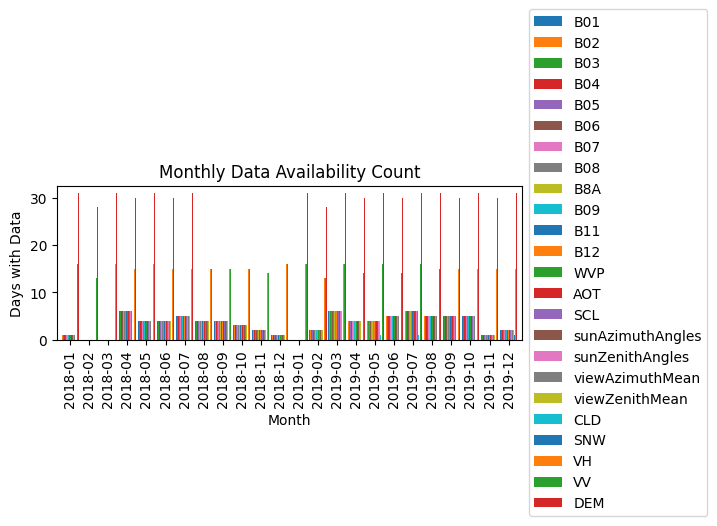

In [4]:
# sanity check
# Get time as pandas DatetimeIndex
time_index = pd.to_datetime(ds.t.values)
months = pd.Series(time_index).dt.to_period("M")

# Prepare a DataFrame to hold counts
counts = pd.DataFrame(index=np.sort(months.unique()))

for var in ds.data_vars:
    dims = ds[var].dims
    if "y" in dims and "x" in dims:
        # Count days with non-NaN data for each month
        valid_per_time = ~np.isnan(ds[var].mean(dim=("y", "x")).values)
        month_counts = pd.Series(valid_per_time, index=months).groupby(level=0).sum()
        counts[var] = month_counts
    else:
        print(f"Skipping {var}: dims={dims}")

# Plot
counts.plot(kind="bar", figsize=(6, 2), width=0.9)
plt.title("Monthly Data Availability Count")
plt.xlabel("Month")
plt.ylabel("Days with Data")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# print(counts)

#### Dimensions

In [5]:
# Print time dimensions of the dataset
print("Time Dimension:", "Startdate:", str(ds.t.values[0]), "Enddate:", str(ds.t.values[-1]), "Total time steps:", ds.sizes["t"])
# Print geospatial dimensions of the dataset
print("Geospatial dimension:", "Height (north-south extent, pixels):", ds.sizes["y"], "Width (east-west extent, pixels):", ds.sizes["x"])
# Print shape of the dataset
print("Dataset shape (t, y, x):", ds.sizes["t"], ds.sizes["y"], ds.sizes["x"])

Time Dimension: Startdate: 2018-01-01T00:00:00.000000000 Enddate: 2019-12-31T00:00:00.000000000 Total time steps: 730
Geospatial dimension: Height (north-south extent, pixels): 187 Width (east-west extent, pixels): 150
Dataset shape (t, y, x): 730 187 150


In [6]:
# Check the actual pixel size/spatial resolution
x_coords = ds.x.values
y_coords = ds.y.values

x_resolution = abs(x_coords[1] - x_coords[0])
y_resolution = abs(y_coords[1] - y_coords[0])

print(f"Pixel size: {x_resolution}m × {y_resolution}m")

Pixel size: 10.0m × 10.0m


In [7]:
# How many pixels in the cube?
n_y = ds.sizes["y"]
n_x = ds.sizes["x"]
total_pixels = n_y * n_x
print(f"Total pixels in the cube: {total_pixels} ({n_y} rows × {n_x} columns)") 

# and if we have 730 days, then total data points = pixels * days
print(f"Total data points in the cube: {total_pixels * ds.sizes['t']} ({total_pixels} pixels × {ds.sizes['t']} days)") 

# how many hectares does the cube cover then?
total_area = total_pixels * x_resolution * y_resolution
print(f"Total area covered by the cube: {total_area / 10000} ha")

Total pixels in the cube: 28050 (187 rows × 150 columns)
Total data points in the cube: 20476500 (28050 pixels × 730 days)
Total area covered by the cube: 280.5 ha


#### Summary stat - inspect different vars, understand ds

In [8]:
# Start w some summary statistics of B vars
print(ds["B02"].mean().item(), ds["B02"].std().item(), ds["B02"].min().item(), ds["B02"].max().item())

print("-" * 80)
band = ds["B03"]

print("Shape:", band.shape)            # (time, y, x)
print("Overall min:", float(band.min()))
print("Overall max:", float(band.max()))
print("Overall mean:", float(band.mean()))

0.06542453914880753 0.05838638171553612 -0.010099999606609344 0.9960999488830566
--------------------------------------------------------------------------------
Shape: (730, 187, 150)
Overall min: -0.003000000026077032
Overall max: 0.990399956703186
Overall mean: 0.08716532588005066


In [9]:
# More detailed stats including negative and missing values for all bands
# do this for B01-B12 including B8A
for band in [f"B{str(i).zfill(2)}" for i in range(1, 13)] + ["B8A"]:
    if band in ds:
        arr = ds[band].values
        negatives = np.sum(arr < 0)
        missings = np.sum(np.isnan(arr))
        valids = np.sum(~np.isnan(arr))
        print(f"{band}: Negative pixels={negatives}, Missing={missings}, Valid={valids}")
    else:
        print(f"{band} not in dataset")

B01: Negative pixels=12161, Missing=19536343, Valid=940157
B02: Negative pixels=2675, Missing=19536404, Valid=940096
B03: Negative pixels=19, Missing=19536310, Valid=940190
B04: Negative pixels=0, Missing=19536307, Valid=940193
B05: Negative pixels=0, Missing=19536307, Valid=940193
B06: Negative pixels=0, Missing=19536307, Valid=940193
B07: Negative pixels=0, Missing=19536307, Valid=940193
B08: Negative pixels=0, Missing=19536307, Valid=940193
B09: Negative pixels=0, Missing=19536307, Valid=940193
B10 not in dataset
B11: Negative pixels=0, Missing=19536307, Valid=940193
B12: Negative pixels=0, Missing=19536307, Valid=940193
B8A: Negative pixels=0, Missing=19536307, Valid=940193


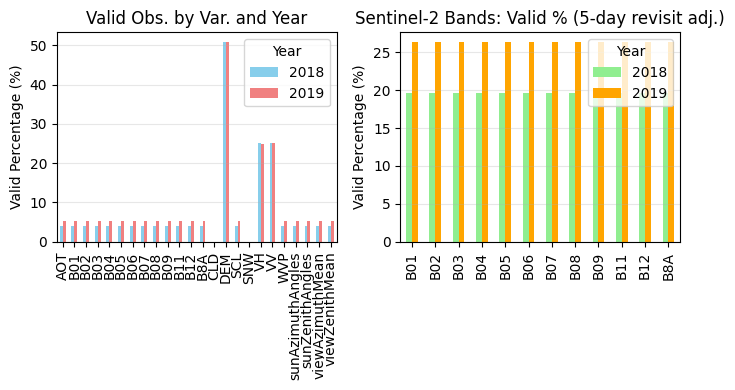

In [10]:
# Table for valid observations per variable per year, Sentinel 2 bands adjusted for a 5-day revisit period
years = [2018, 2019]
all_results = []

for year in years:
    year_ds = ds.sel(t=slice(f"{year}-01-01", f"{year}-12-31"))
    
    for var in year_ds.data_vars:
        if 'x' in year_ds[var].dims and 'y' in year_ds[var].dims:
            total_valid = np.sum(~np.isnan(year_ds[var].values)) 
            total_possible = year_ds[var].values.size
            total_possible_revisit = year_ds[var].values.size/5  # assuming a 5-day revisit period
            
            all_results.append({
                'Year': year,
                 'Variable': var,
                'Valid_Observations': total_valid,
                'Valid_Percent': (total_valid / total_possible) * 100,
                'Valid_Percent_Revisit': (total_valid / total_possible_revisit) * 100 if var.startswith('B') else np.nan
            })

results_df = pd.DataFrame(all_results).sort_values(['Year', 'Variable'])
results_df['Valid_Percent'] = results_df['Valid_Percent'].round(2)
results_df['Valid_Percent_Revisit'] = results_df['Valid_Percent_Revisit'].round(2)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(7, 4))

# P1: Valid percentage by variable and year
pivot_df = results_df.pivot(index='Variable', columns='Year', values='Valid_Percent')
pivot_df.plot(kind='bar', ax=axes[0], color=['skyblue', 'lightcoral'])
axes[0].set_title('Valid Obs. by Var. and Year')
axes[0].set_ylabel('Valid Percentage (%)')
axes[0].set_xlabel('')
axes[0].legend(title='Year')
axes[0].grid(axis='y', alpha=0.3)

# P2: Sentinel-2 bands with revisit adjustment (assumption every 5 days)
s2_data = results_df[results_df['Variable'].str.startswith('B')].dropna(subset=['Valid_Percent_Revisit'])
if not s2_data.empty:
    pivot_s2 = s2_data.pivot(index='Variable', columns='Year', values='Valid_Percent_Revisit')
    pivot_s2.plot(kind='bar', ax=axes[1], color=['lightgreen', 'orange'])
    axes[1].set_title('Sentinel-2 Bands: Valid % (5-day revisit adj.)')
    axes[1].set_ylabel('Valid Percentage (%)')
    axes[1].set_xlabel('')
    axes[1].legend(title='Year')
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# How to deal with negative values? 
# Set negative values to NaN for all Sentinel-2 bands
bands_to_process = [f"B{str(i).zfill(2)}" for i in range(1, 10)] + ["B8A"] + [f"B{str(i).zfill(2)}" for i in range(11, 13)]

for band in bands_to_process:
    if band in ds:
        ds[band] = ds[band].where(ds[band] >= 0, np.nan)
        print(f"{band}: negative values set to NaN")

B01: negative values set to NaN
B02: negative values set to NaN
B03: negative values set to NaN
B04: negative values set to NaN
B05: negative values set to NaN
B06: negative values set to NaN
B07: negative values set to NaN
B08: negative values set to NaN
B09: negative values set to NaN
B8A: negative values set to NaN
B11: negative values set to NaN
B12: negative values set to NaN


In [12]:
# Check the time variable in the dataset
print(ds.t)
print("First timestamp:", ds.t.values[0])
print("Last timestamp:", ds.t.values[-1])

<xarray.DataArray 't' (t: 730)> Size: 6kB
array(['2018-01-01T00:00:00.000000000', '2018-01-02T00:00:00.000000000',
       '2018-01-03T00:00:00.000000000', ..., '2019-12-29T00:00:00.000000000',
       '2019-12-30T00:00:00.000000000', '2019-12-31T00:00:00.000000000'],
      shape=(730,), dtype='datetime64[ns]')
Coordinates:
  * t        (t) datetime64[ns] 6kB 2018-01-01 2018-01-02 ... 2019-12-31
Attributes:
    standard_name:  t
    long_name:      t
    axis:           T
First timestamp: 2018-01-01T00:00:00.000000000
Last timestamp: 2019-12-31T00:00:00.000000000


In [13]:
# Check out WVP (Water Vapor Product)
ds["WVP"].mean().item(), ds["WVP"].std().item(), ds["WVP"].min().item(), ds["WVP"].max().item()

(1521.4356689453125, 761.0496215820312, 136.0, 4000.0)

Mean Cloud coverage: 2.779, Std: 2.045, Min: 1.000, Max: 10.000


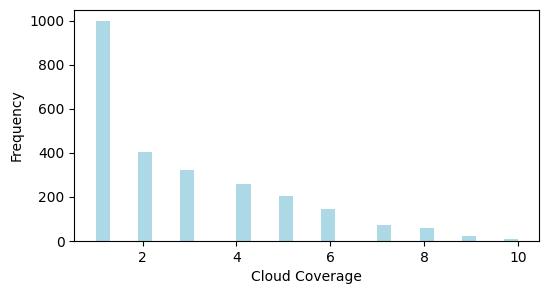

In [14]:
# Lets talk about clouds 
# calculate some stats for cloud band

mean = ds["CLD"].mean().item()
std = ds["CLD"].std().item()
min_ = ds["CLD"].min().item()
max_ = ds["CLD"].max().item()
print(f"Mean Cloud coverage: {mean:.3f}, Std: {std:.3f}, Min: {min_:.3f}, Max: {max_:.3f}")

# Quick histogram of cloud coverage 
plt.figure(figsize=(6, 3))
plt.hist(ds["CLD"].values.flatten(), bins=30, color='lightblue')
plt.xlabel("Cloud Coverage")
plt.ylabel("Frequency")
plt.show()

Scene classification: Min: 4.000, Max: 5.000


Text(0, 0.5, 'Frequency')

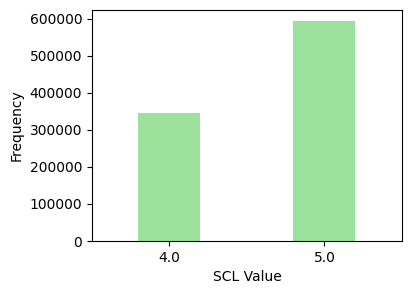

In [15]:
# check out SCL band
min_ = ds["SCL"].min().item()
max_ = ds["SCL"].max().item()
print(f"Scene classification: Min: {min_:.3f}, Max: {max_:.3f}")

# Histogram of SCL values
plt.figure(figsize=(4, 3))
sns.countplot(x=ds["SCL"].values.flatten(), color='lightgreen', width=0.4)
plt.xlabel("SCL Value")
plt.ylabel("Frequency")

## Some Visualizations

In [16]:
# HELPERS

# Clearest Day in summer 2018 (June-August)
def pick_clearest_summer_day(ds, year=2018, cld_var="CLD", max_cloud=2):
    summer_ds = ds.sel(t=slice(f"{year}-06-01", f"{year}-08-31"))
    cld_mean = summer_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = summer_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap

# define clearest day picker - fleeexibleeeee
def pick_clearest_day(ds, start, end, cld_var="CLD", max_cloud=2):
    period_ds = ds.sel(t=slice(start, end))
    cld_mean = period_ds[cld_var].mean(dim=("y", "x"))
    good = cld_mean.where(cld_mean <= max_cloud, drop=True)
    if good.t.size == 0:
        best_t = cld_mean.idxmin()
    else:
        best_t = good.idxmin()
    snap = period_ds.sel(t=best_t, method="nearest")
    print(f"Picked {np.datetime_as_string(snap['t'].values)} (mean {cld_var}={float(cld_mean.sel(t=snap['t']).values):.3f})")
    return snap


In [17]:
# Define a colormap that treats NaNs as transparent
cmap = matplotlib.colormaps["RdYlGn"].copy()
cmap.set_bad(color=(0,0,0,0))  # RGBA, fully transparent

Picked 2018-07-13T00:00:00.000000000 (mean CLD=1.000)


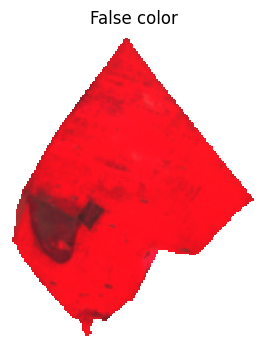

In [18]:
# False colors - like on the copernicus page
# Pick a clear day (or any day you want)
snap = pick_clearest_summer_day(ds, year=2018)

# Extract bands for false color: NIR (B08), Red (B04), Green (B03)
nir = snap["B08"].values
red = snap["B04"].values
green = snap["B03"].values

# Highlight/stretch function (similar to Copernicus)
def highlight_compression(arr, maxInput=0.4, clipInput=0.8, maxOutput=1.0):
    arr = arr / (maxInput + 1e-6)
    arr = np.clip(arr, 0, clipInput / maxInput)
    arr = arr * maxOutput
    return np.clip(arr, 0, 1)

# Stack into RGB (False color: NIR, Red, Green)
rgb_fc = np.dstack([
    highlight_compression(nir),
    highlight_compression(red),
    highlight_compression(green)
])

# Mask where any band is NaN
mask = np.isnan(nir) | np.isnan(red) | np.isnan(green)
rgb_fc_masked = rgb_fc.copy()
rgb_fc_masked[mask] = np.nan  # Set missing pixels to NaN

plt.figure(figsize=(4, 4))
plt.imshow(rgb_fc_masked)
plt.title("False color")
plt.axis("off")
plt.show()

Picked 2018-07-13T00:00:00.000000000 (mean CLD=1.000)


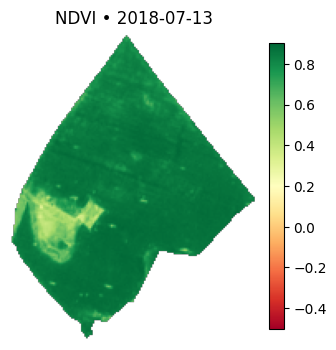

In [19]:
# Visualize NDVI (vegetation) for a clear summer day in 2018
# Pick clear summer day and plot NDVI

# NDVI = (NIR - RED) / (NIR + RED)
# NDVI = (B08 - B04) / (B08 + B04)

snap = pick_clearest_summer_day(ds, year=2018)
ndvi = (snap['B08'] - snap['B04']) / (snap['B08'] + snap['B04'])
plt.figure(figsize=(4, 4))
im = plt.imshow(ndvi, vmin=-0.5, vmax=0.9, cmap="RdYlGn")
plt.title(f"NDVI • {np.datetime_as_string(snap['t'].values, unit='D')}")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

In [20]:
print("NDVI mean:", np.nanmean(ndvi))
print("NDVI min:", np.nanmin(ndvi))
print("NDVI max:", np.nanmax(ndvi))

NDVI mean: 0.821576
NDVI min: 0.31924668
NDVI max: 0.89607686


Picked 2018-07-13T00:00:00.000000000 (mean CLD=1.000)


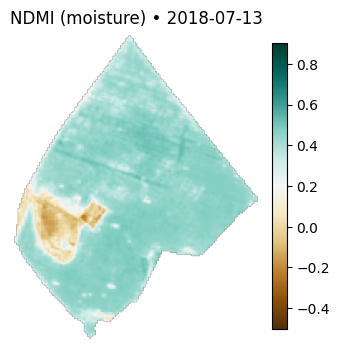

In [21]:
# look at the normalized difference moisture index (NDMI) for moisture
# NDMI = (NIR - SWIR) / (NIR + SWIR)
# NDMI = (B08 - B11) / (B08 + B11)

snap = pick_clearest_summer_day(ds, year=2018)
ndmi = (snap['B08'] - snap['B11']) / (snap['B08'] + snap['B11'])
plt.figure(figsize=(4, 4))
im = plt.imshow(ndmi, vmin=-0.5, vmax=0.9, cmap="BrBG")
plt.title(f"NDMI (moisture) • {np.datetime_as_string(snap['t'].values, unit='D')}")
plt.axis("off")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.show()

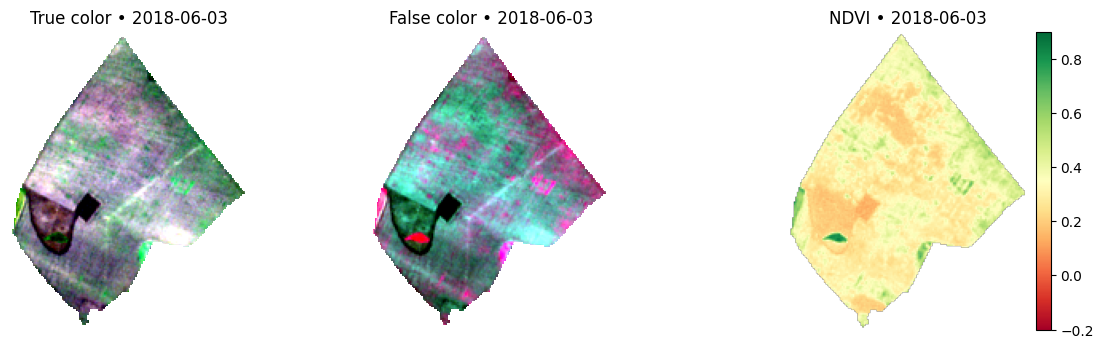

In [22]:
# Pick day with most valid data
summer = ds.sel(t=slice("2018-06-01", "2018-08-31"))
valid_counts = [(~np.isnan(summer.isel(t=i)['B04'].values)).sum() + 
                (~np.isnan(summer.isel(t=i)['B08'].values)).sum() 
                for i in range(len(summer.t))]
best = summer.isel(t=np.argmax(valid_counts))

# Stretch function
def stretch(arr, p=2):
    vmin, vmax = np.nanpercentile(arr, [p, 100-p])
    return np.clip((arr - vmin) / (vmax - vmin + 1e-6), 0, 1)

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
date = np.datetime_as_string(best['t'].values, unit='D')

# True color
rgb_tc = np.dstack([stretch(best[b].values) for b in ["B04", "B03", "B02"]])
axes[0].imshow(rgb_tc)
axes[0].set_title(f"True color • {date}")
axes[0].axis("off")

# False color
rgb_fc = np.dstack([stretch(best[b].values) for b in ["B08", "B04", "B03"]])
axes[1].imshow(rgb_fc)
axes[1].set_title(f"False color • {date}")
axes[1].axis("off")

# NDVI
ndvi = (best['B08'] - best['B04']) / (best['B08'] + best['B04'])
im = axes[2].imshow(ndvi, vmin=-0.2, vmax=0.9, cmap="RdYlGn")
axes[2].set_title(f"NDVI • {date}")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.02)

plt.tight_layout()
plt.show()

/var/folders/rj/kgqxyxc93n940yr_71tx_22r0000gn/T/ipykernel_12101/3302544013.py:7: RuntimeWarning: Mean of empty slice
  mean_ndvi = np.nanmean(ndvi, axis=0)  # mean over time


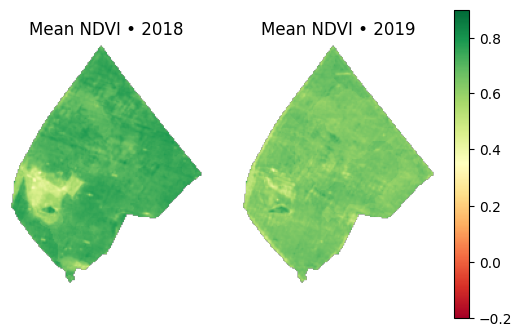

In [23]:
# Compute mean NDVI per pixel for a given season (summer)
def mean_ndvi_for_year(ds, year):
    year_ds = ds.sel(t=slice(f"{year}-06-01", f"{year}-08-31"))
    b08 = year_ds["B08"].values
    b04 = year_ds["B04"].values
    ndvi = (b08 - b04) / (b08 + b04)
    mean_ndvi = np.nanmean(ndvi, axis=0)  # mean over time
    return mean_ndvi

# Plot mean NDVI for both years
fig, axes = plt.subplots(1, 2, figsize=(6, 4))
for i, year in enumerate([2018, 2019]):
    mean_ndvi = mean_ndvi_for_year(ds, year)
    im = axes[i].imshow(mean_ndvi, vmin=-0.2, vmax=0.9, cmap=cmap)
    axes[i].set_title(f"Mean NDVI • {year}")
    axes[i].axis("off")
fig.colorbar(im, ax=axes, fraction=0.046, pad=0.04)
plt.show()

In [24]:
def valid_obs_count(ds, year, band="B04"):
    """Count valid (non-NaN) observations per pixel for a given year and band."""
    year_ds = ds.sel(t=slice(f"{year}-01-01", f"{year}-12-31"))
    arr = year_ds[band].values  # shape: (t, y, x)
    return np.sum(~np.isnan(arr), axis=0)  # shape: (y, x)

for year in [2018, 2019]:
    count = valid_obs_count(ds, year)
    print(f"{year}: mean valid obs per pixel = {np.mean(count):.1f}, median = {np.median(count):.1f}")

2018: mean valid obs per pixel = 14.3, median = 0.0
2019: mean valid obs per pixel = 19.2, median = 0.0


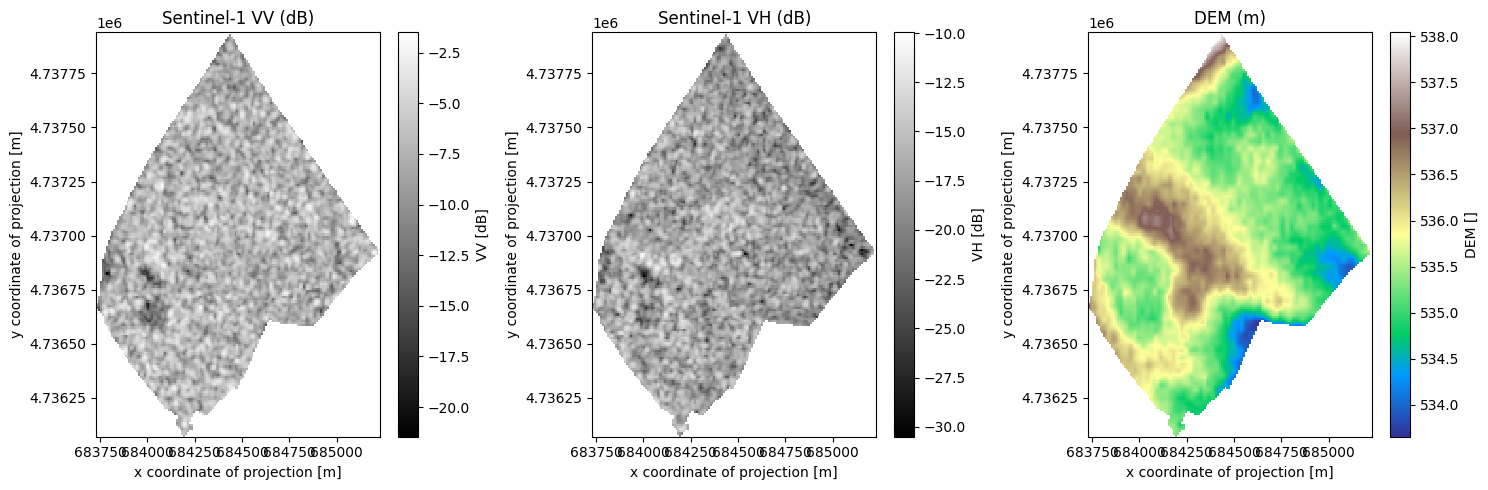

In [25]:
# Visualize Sentinel-1 VV, VH, and DEM

time0 = ds.isel(t=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

time0["VV"].plot(ax=axes[0], cmap="gray")
axes[0].set_title("Sentinel-1 VV (dB)")

time0["VH"].plot(ax=axes[1], cmap="gray")
axes[1].set_title("Sentinel-1 VH (dB)")

time0["DEM"].plot(ax=axes[2], cmap="terrain")
axes[2].set_title("DEM (m)")

plt.tight_layout()
plt.show()

## Alignment of the pixels

We want to check how our pixels in the data cube actually align with the "real world". There is some uncertainty, due to geometric correction, resampling, reprojection. In addition to us relying on different sensors (S1, S2, DEM).

This is highly relevant for sampling, because if for example we sample on "high NDVI" areas, but the actual coordinates are off by a couple of meters, we might end up sampling the wrong location.

There are some theoretical approaches for validation, e.g. high precision GNSS (Galileo, the EU´s Global Navigation Satellite System (GNSS)).

### Understanding Coordinate Reference Systems (CRS)

CRS defines how coordinates relate to actual locations on Earth (can be seen as a translation system, between mathematical coordinates and real-world geography)

1. WGS84 (World Geodetic System 1984)
- A geodetic datum, defines Earth's shape and size
- Uses a spheroid (ellipsoid) to approximate Earth's shape
- The GPS system uses WGS84
- Coordinates in latitude/longitude (degrees)
- E.g.: EPSG:4326

2. UTM Zones (Universal Transverse Mercator)
- Projects the 3D Earth onto a 2D plane
- Divides Earth into 60 zones (6° wide each)
- Each zone has its own coordinate system
- Uses meters (Easting, Northing) instead of degrees

Our field is in Bulgaria:
Original shapefile: EPSG:32635 = UTM Zone 35N
Your data cube: EPSG:32634 = UTM Zone 34N


3. EPSG Codes
Standardized numeric IDs for CRS definitions
EPSG:32634 = UTM Zone 34N, WGS84
EPSG:32635 = UTM Zone 35N, WGS84
EPSG:4326 = WGS84 Geographic (lat/lon)

### Relationship between CRS, Datum (WGS84), Projection (UTM), and EPSG Codes

| Concept       | What it Represents                              | Example / Note                            |
|---------------|--------------------------------------------------|--------------------------------------------|
| **CRS**       | Full coordinate system (datum + projection)      | “WGS84 UTM Zone 34N”                       |
| **Datum**     | Earth model (shape + reference ellipsoid)        | **WGS84** (used by GPS and UTM)           |
| **Projection**| Mathematical transformation from Earth → 2D map  | **UTM** (zones 1–60, each 6° wide)         |
| **EPSG Code** | Numerical ID referencing a specific CRS          | **32634** = WGS84 + UTM Zone 34N (meters)  |
| **Geographic CRS** | CRS using latitude/longitude (degrees)     | **EPSG:4326** (WGS84 geographic)           |
| **Projected CRS**  | CRS using x/y coordinates (meters)         | **EPSG:32634**, **EPSG:32635** (UTM zones) |

**Conceptual hierarchy:**  
Datum (WGS84) → Projection (UTM Zone XX) → CRS → EPSG number.

In [26]:
# Load the shapefile for the field boundary
shapefile_path = "/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp"
field = gpd.read_file(shapefile_path)

In [27]:
# Understand difference between shapefile and datacube CRS
print("CRS of cube:", ds.rio.crs)
print("x spacing:", float(ds.x[1] - ds.x[0]))
print("y spacing:", float(ds.y[0] - ds.y[1]))

print("SHAPEFILE ORIGINAL CRS:", field.crs)

CRS of cube: None
x spacing: 10.0
y spacing: 10.0
SHAPEFILE ORIGINAL CRS: EPSG:32635


In [28]:
# What are the different coordinates for the shapefile and the data cube

# Get coordinate ranges from data cube
cube_x_min = ds.x.min().item()
cube_x_max = ds.x.max().item()
cube_y_min = ds.y.min().item()
cube_y_max = ds.y.max().item()

# Get coordinate ranges from shapefile
field_bounds = field.total_bounds  # [minx, miny, maxx, maxy]
field_x_min, field_y_min, field_x_max, field_y_max = field_bounds

# Display the coordinates
print("Data cube coordinates:")
print(f"    X range: {cube_x_min:.2f} to {cube_x_max:.2f} m")
print(f"    Y range: {cube_y_min:.2f} to {cube_y_max:.2f} m")

print('Shapefile coordinates:')
print(f"    X range: {field.total_bounds[0]:.2f} to {field.total_bounds[2]:.2f} m")
print(f"    Y range: {field.total_bounds[1]:.2f} to {field.total_bounds[3]:.2f} m")

# Calculate the difference
diff_x = (field_x_min + field_x_max)/2 - (cube_x_min + cube_x_max)/2
diff_y = (field_y_min + field_y_max)/2 - (cube_y_min + cube_y_max)/2
distance = np.sqrt(diff_x**2 + diff_y**2)

print("Differences between shapefile and data cube coordinates:")
print(f"    X difference: {diff_x:,.2f} m ({abs(diff_x)/1000:.1f} km)")
print(f"    Y difference: {diff_y:,.2f} m ({abs(diff_y)/1000:.1f} km)")
print(f"    Distance apart: {distance:,.2f} m ({distance/1000:.1f} km)")

Data cube coordinates:
    X range: 683735.00 to 685225.00 m
    Y range: 4736075.00 to 4737935.00 m
Shapefile coordinates:
    X range: 192764.60 to 194273.86 m
    Y range: 4740435.35 to 4742277.78 m
Differences between shapefile and data cube coordinates:
    X difference: -490,960.77 m (491.0 km)
    Y difference: 4,351.56 m (4.4 km)
    Distance apart: 490,980.05 m (491.0 km)


In [29]:
# Import raw cube
ds_raw = xr.open_dataset("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/data/smartsoil_experiment/agrovar_sofia26/fused_S1-S2-DEM_2018_2018_cube-raw.nc")
print(ds_raw.rio.crs)

None


In [30]:
# Assign the correct CRS back to the cube
ds = ds.rio.write_crs("EPSG:32634")

# Transform the shapefile 
field = gpd.read_file("/Users/annas/Library/CloudStorage/OneDrive-Personal/GIT/eo-mmrv/input/smartsoil_experiment/agrovar_sofia26/field26.shp")
field = field.to_crs(ds.rio.crs)

In [31]:
# How can the CRS of the cube and the shapefile be different and yet still align? do they have to be the same to have the same point in the right location?
# extract some coordinates/GPS locations - see where they are located?
# how can we potentially validate the alignment and the coordinates using a GNSS (e.g. galileo gnss)
# really make sure that the sampling points that we would extract, are in the exact right location

### Radar Data Analysis (Sentinel-1)

Sentinel-1 radar provides information about:
- **VV polarization**: Surface roughness (sensitive to soil moisture, tillage)
- **VH polarization**: Volume scattering (sensitive to vegetation structure)
- **VH/VV ratio**: Vegetation index independent of weather/clouds

Using timestamp with valid radar: 2018-06-04


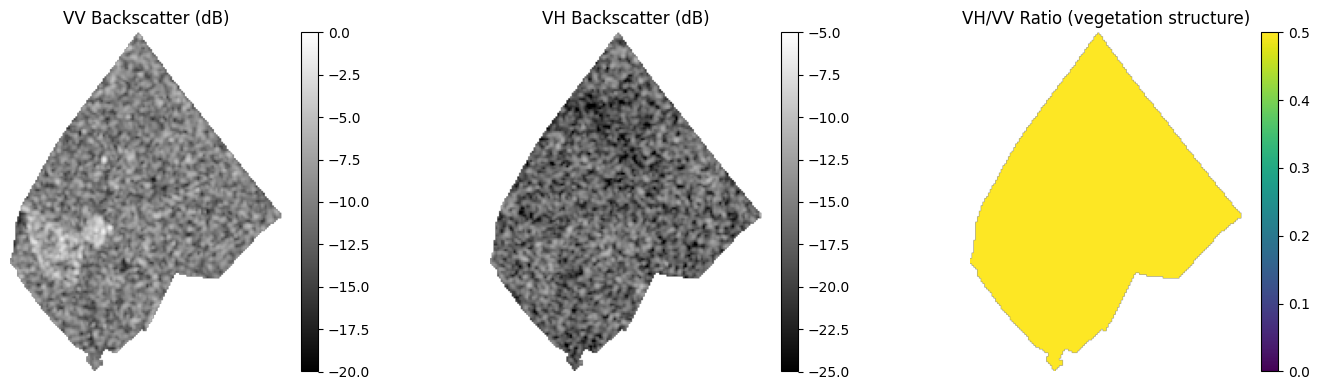

In [32]:
# Calculate and visualize VH/VV ratio
# Need to pick a timestamp with valid radar data (not just clear optical)

# Find summer timestamps with valid VV data
summer_2018 = ds.sel(t=slice("2018-06-01", "2018-08-31"))
vv_mean = summer_2018['VV'].mean(dim=['x', 'y'])
valid_vv = ~np.isnan(vv_mean)

if valid_vv.sum() == 0:
    print("No valid radar data in summer 2018!")
else:
    # Pick first valid timestamp
    valid_times = summer_2018['t'][valid_vv]
    snap = summer_2018.sel(t=valid_times[0])
    print(f"Using timestamp with valid radar: {np.datetime_as_string(snap['t'].values, unit='D')}")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # VV backscatter
    im0 = axes[0].imshow(snap['VV'], cmap='gray', vmin=-20, vmax=0)
    axes[0].set_title('VV Backscatter (dB)')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    
    # VH backscatter
    im1 = axes[1].imshow(snap['VH'], cmap='gray', vmin=-25, vmax=-5)
    axes[1].set_title('VH Backscatter (dB)')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # VH/VV ratio (vegetation indicator)
    vh_vv_ratio = snap['VH'] / snap['VV']
    im2 = axes[2].imshow(vh_vv_ratio, cmap='viridis', vmin=0, vmax=0.5)
    axes[2].set_title('VH/VV Ratio (vegetation structure)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

---

## Summary

This cube covers Field 26 for 2018-2019 with 10m resolution from Sentinel-1, Sentinel-2, and Copernicus DEM.

**Data availability:**
- Sentinel-2 bands show ~20-40% valid observations after accounting for clouds and bad pixels
- Sentinel-1 radar data is more consistent (no cloud issues)
- DEM is static, always there
- Negative values in spectral bands (<1% of data) - set these to NaN

**Cloud masking:**
- Mean cloud probability ~15-20%, but highly variable

**Coordinate alignment:**
- Shapefile was in EPSG:32635 (UTM Zone 35N), cube is EPSG:32634 (UTM Zone 34N)
- Reprojected shapefile to match cube CRS
- Need to visually verify alignment with overlay


**For soil sampling design:**
- NDVI from cloud-free summer observations is solid stratification variable
- Consider VH/VV ratio as complementary
- Account for geolocation uncertainty when placing samples in field (further work needed)
- Validate coordinates with GNSS if high precision needed